# Day 5 · Notebook 4 — Generative AI from scratch ✨
### ML Bootcamp · Day 5 of 5

ChatGPT, Claude and Gemini all do one thing over and over: **predict the next token** (a word or piece of a word), add it, and predict again.

We'll build the same idea at a tiny scale — a model that **invents new names**, one letter at a time.

In this notebook you will:
1. Build a **counting model** (bigram): which letter usually follows which? *(Part 1)*
2. Build a small **neural** language model with **embeddings** *(Part 2)*
3. Play with **temperature**: safe vs creative *(Part 3)*
4. *(Colab bonus)* Talk to a real large language model *(Part 4)*

> A GPU helps in Part 2 but isn't required. ✍️ = exercise (solutions at the end).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import urllib.request, time
plt.rcParams["font.size"] = 12

url = "https://raw.githubusercontent.com/karpathy/makemore/master/names.txt"
words = urllib.request.urlopen(url).read().decode().split()
print(len(words), "names, e.g.", words[:8])

32033 names, e.g. ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


---
## Part 1 · The simplest language model: counting
Our **tokens** are the 26 letters plus **"."**, which marks the start and end of a name.
We count every pair: in "emma" the pairs are `.e  em  mm  ma  a.`

Vocabulary: 27 tokens


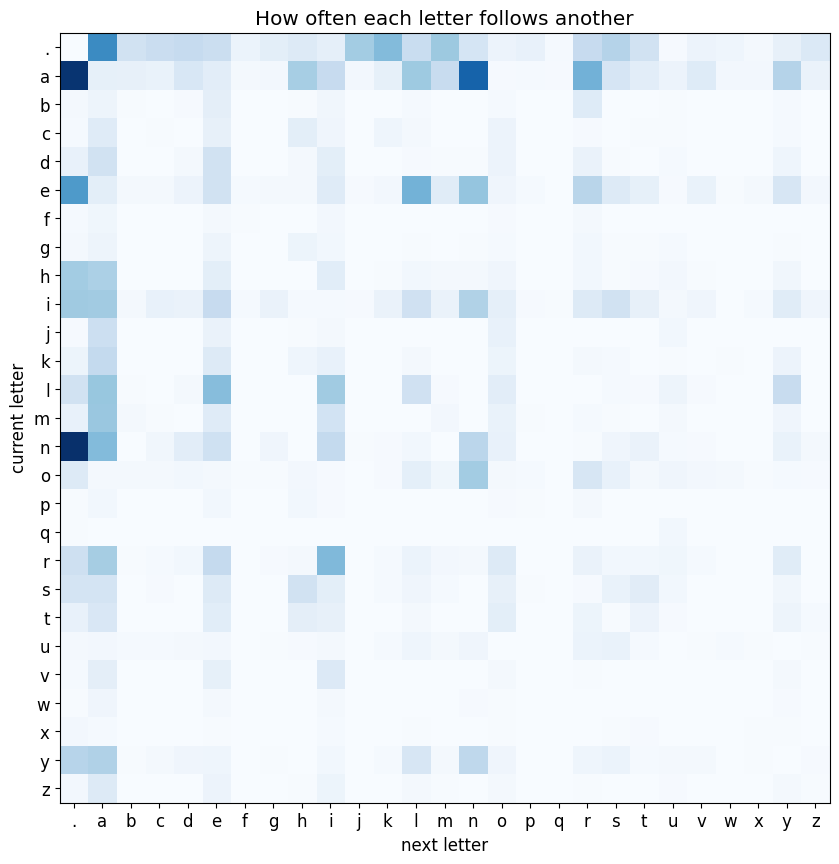

In [2]:
chars = sorted(set("".join(words)))
stoi = {c: i + 1 for i, c in enumerate(chars)}; stoi["."] = 0      # letter -> number
itos = {i: c for c, i in stoi.items()}                              # number -> letter
V = len(stoi)
print("Vocabulary:", V, "tokens")

counts = np.zeros((V, V))
for w in words:
    seq = ["."] + list(w) + ["."]
    for a, b in zip(seq, seq[1:]):
        counts[stoi[a], stoi[b]] += 1

plt.figure(figsize=(11, 10))
plt.imshow(counts, cmap="Blues")
labels = [itos[i] for i in range(V)]
plt.xticks(range(V), labels); plt.yticks(range(V), labels)
plt.xlabel("next letter"); plt.ylabel("current letter"); plt.title("How often each letter follows another")
plt.show()

In [3]:
P = (counts + 1) / (counts + 1).sum(axis=1, keepdims=True)    # turn counts into probabilities (+1 = never exactly 0)

print("Most likely first letters:", [(itos[i], f"{P[0, i]:.1%}") for i in np.argsort(-P[0])[:5]])
print("Most likely after 'a':    ", [(itos[i], f"{P[stoi['a'], i]:.1%}") for i in np.argsort(-P[stoi['a']])[:5]], " ('.' = end)")

rng = np.random.default_rng(42)
def generate_bigram():
    out, i = [], 0
    while True:
        i = rng.choice(V, p=P[i])       # pick the next letter using the probabilities
        if i == 0: return "".join(out)
        out.append(itos[i])
print("\nBigram names:", [generate_bigram() for _ in range(10)])

Most likely first letters: [('a', '13.8%'), ('k', '9.2%'), ('m', '7.9%'), ('j', '7.6%'), ('s', '6.4%')]
Most likely after 'a':     [('.', '19.6%'), ('n', '16.0%'), ('r', '9.6%'), ('l', '7.5%'), ('h', '6.9%')]  ('.' = end)

Bigram names: ['reslaynn', 'jaylon', 'k', 'siquxxtal', 'brlyaha', 'alanasmasseen', 'c', 'rinlema', 'mbllilicakaisa', 'eendoonn']


🧠 Some look like names, many are nonsense — the model only remembers **one** letter back.

### How good is a language model? The loss
The **loss** (cross-entropy, Day 4) = on average, how surprised is the model by the real next letter? Lower is better. Guessing uniformly among 27 tokens gives ln(27) ≈ 3.30.

In [4]:
log_probs = [np.log(P[stoi[a], stoi[b]]) for w in words for a, b in zip("." + w, w + ".")]
bigram_loss = -np.mean(log_probs)
print(f"Random guessing loss: {np.log(27):.3f}")
print(f"Bigram loss:          {bigram_loss:.3f}")

Random guessing loss: 3.296
Bigram loss:          2.455


---
## Part 2 · A neural language model
Now a small neural network looks at the **previous 3 letters** and predicts the next one (the idea from Bengio et al., 2003).
- **Embedding**: each letter becomes a list of 10 learned numbers — letters that behave alike get similar numbers. LLMs do the same with words.
- Then a hidden layer (200 neurons) and an output of 27 scores, one per possible next letter.

In [5]:
block = 3
X, Y = [], []
for w in words:
    context = [0] * block
    for ch in w + ".":
        X.append(context); Y.append(stoi[ch])
        context = context[1:] + [stoi[ch]]
X, Y = np.array(X), np.array(Y)
print("Training examples:", len(X))
for i in range(6):
    print("".join(itos[j] for j in X[i]), "->", itos[Y[i]])

Training examples: 228146
... -> e
..e -> m
.em -> m
emm -> a
mma -> .
... -> o


Weights: 11897
Trained in 49 s


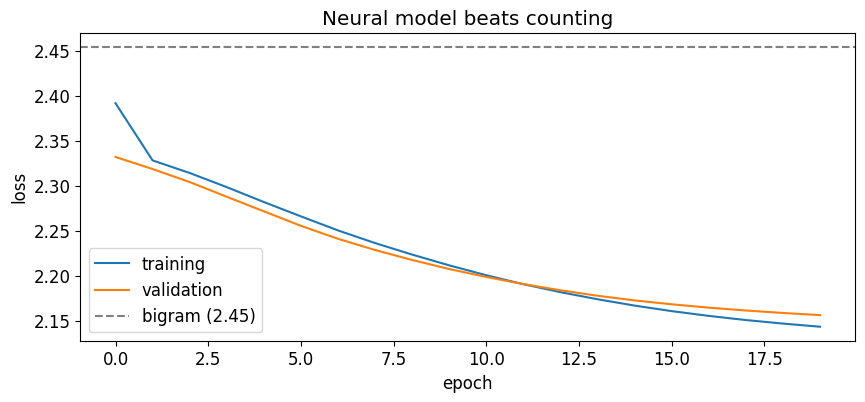

Neural model validation loss: 2.156


In [6]:
import keras
from keras import layers
keras.utils.set_random_seed(42)

idx = np.random.default_rng(0).permutation(len(X))
split = int(0.9 * len(X)); tr, va = idx[:split], idx[split:]

lm = keras.Sequential([
    keras.Input(shape=(block,)),
    layers.Embedding(V, 10),            # 27 letters x 10 numbers each
    layers.Flatten(),
    layers.Dense(200, activation="tanh"),
    layers.Dense(V),                    # a score for each of the 27 possible next letters
])
lm.compile(optimizer=keras.optimizers.Adam(0.003),
           loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True))
print("Weights:", lm.count_params())

start = time.time()
h = lm.fit(X[tr], Y[tr], validation_data=(X[va], Y[va]), epochs=20, batch_size=256, verbose=0)
print(f"Trained in {time.time() - start:.0f} s")

plt.figure(figsize=(10, 4))
plt.plot(h.history["loss"], label="training"); plt.plot(h.history["val_loss"], label="validation")
plt.axhline(bigram_loss, color="grey", ls="--", label=f"bigram ({bigram_loss:.2f})")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Neural model beats counting"); plt.show()
print(f"Neural model validation loss: {h.history['val_loss'][-1]:.3f}")

In [7]:
known = set(words)
def generate(temperature=1.0, n=10, seed=1):
    r = np.random.default_rng(seed)
    names = []
    for _ in range(n):
        context, out = [0] * block, []
        while len(out) < 20:
            logits = lm.predict(np.array([context]), verbose=0)[0] / temperature
            p = np.exp(logits - logits.max()); p /= p.sum()
            i = r.choice(V, p=p)
            if i == 0: break
            out.append(itos[i]); context = context[1:] + [i]
        names.append("".join(out))
    return names

names = generate(1.0)
print("Neural model names:", names)
print("Brand-new (not in the training list):", sum(n not in known for n in names), "of", len(names))

Neural model names: ['kyeth', 'sha', 'omarib', 'iler', 'juvice', 'zeckrit', 'keanna', 'sharanilan', 'avorea', 'mercelys']
Brand-new (not in the training list): 9 of 10


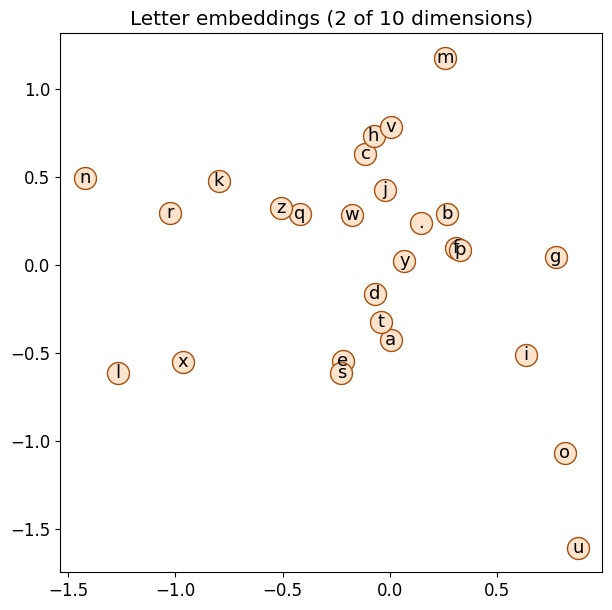

In [8]:
# Look inside: the letter embeddings (first 2 of the 10 numbers)
E = lm.layers[0].get_weights()[0]
plt.figure(figsize=(7, 7))
plt.scatter(E[:, 0], E[:, 1], s=250, c="#FCE3CB", edgecolors="#A84E0F")
for i in range(V):
    plt.text(E[i, 0], E[i, 1], itos[i], ha="center", va="center", fontsize=13)
plt.title("Letter embeddings (2 of 10 dimensions)"); plt.show()

🧠 Letters the model treats alike end up close together. In our run **i, o and u** sit apart from the consonants in one corner. We only see 2 of the 10 numbers here, so many patterns stay hidden. Nobody told the model anything about letters: it learned these numbers from data. LLMs learn embeddings for words in the same way.

---
## Part 3 · Temperature: safe vs creative
Before sampling we divide the scores by the **temperature** T:
- **T < 1** → the model sticks to its favourite letters: safe, common, often real names
- **T = 1** → the model's true probabilities
- **T > 1** → flatter probabilities: more surprising, eventually nonsense

Chatbots let developers set this same "temperature" knob.

In [9]:
for T in [0.5, 1.0, 1.5]:
    names = generate(T)
    print(f"T = {T}:  new {sum(n not in known for n in names)}/10  ", names)

T = 0.5:  new 5/10   ['john', 'gracarles', 'jana', 'maryn', 'jaiya', 'kenzela', 'kendren', 'ashi', 'mahira', 'carmon']
T = 1.0:  new 9/10   ['kyeth', 'sha', 'omarib', 'iler', 'juvice', 'zeckrit', 'keanna', 'sharanilan', 'avorea', 'mercelys']
T = 1.5:  new 8/10   ['kydvelten', 'rihlan', 'ihanahzyna', 'cylannet', 'khartibremmarlocna', 'tutic', 'mise', 'moxalvin', 'nyron', 'ray']


✍️ **Exercise 1:** try `temperature=0.1` and `temperature=3.0`. What happens at the extremes?

✍️ **Exercise 2:** give the model more memory: change `block = 3` to `block = 5` (re-run Part 2). Does the validation loss go down?

---
## Part 4 · (Colab bonus) A real large language model
Our model has ~12,000 weights and knows only names. Modern LLMs have **billions** of weights, use **Transformers** (attention) and were trained on a large part of the internet — then taught to follow instructions with human feedback (**RLHF** — the reinforcement learning from Notebook 3!).

Colab includes free access to Google's models through `google.colab.ai`. This only works inside Colab.

In [10]:
try:
    from google.colab import ai
    reply = ai.generate_text("In 3 short bullet points, explain to a Nigerian engineering student "
                             "how a large language model generates text.")
    print(reply)
except Exception as e:
    print("This cell only works in Google Colab (", type(e).__name__, ")")

Here is how a Large Language Model (LLM) generates text, explained for an engineering student:

*   **Vectorization (Words to Numbers):** Just like converting physical signals to digital data in DSP (Digital Signal Processing), the LLM translates raw text into numerical vectors (tokens) so it can process language as mathematical coordinates in a high-dimensional space.
*   **Transformer Matrix Math:** Your prompt is fed into a neural network of billions of trained weights. Using massive matrix multiplication and attention mechanisms, the model calculates the exact statistical probability of what the next word should be. 
*   **Autoregressive Feedback Loop:** The model outputs only *one* word (token) at a time. It then instantly feeds that word back into its own input queue as a feedback loop, repeating this recursive process to generate the next word until the text is complete.


✍️ **Exercise 3 (Colab):** ask the model to invent 10 Yoruba, Igbo or Hausa names and explain their meanings. Then check the meanings with someone who speaks the language — do you trust every answer? This is **hallucination**: LLMs can sound confident and still be wrong.

---
## ✅ Summary
- A language model predicts the next token; generating = predict, sample, repeat.
- Counting (bigram) works a little; a neural model with embeddings works better (lower loss).
- Temperature trades safety for creativity.
- Real LLMs are the same idea, scaled up enormously: Transformers + huge data + RLHF.

---
## Solutions

In [ ]:
# Exercise 1
print("T = 0.1:", generate(0.1))   # almost always the same few very common names
print("T = 3.0:", generate(3.0))   # nearly random letters

In [ ]:
# Exercise 2: longer context (block = 5) - usually a slightly lower validation loss
def make_xy(b):
    Xb, Yb = [], []
    for w in words:
        ctx = [0] * b
        for ch in w + ".":
            Xb.append(ctx); Yb.append(stoi[ch]); ctx = ctx[1:] + [stoi[ch]]
    return np.array(Xb), np.array(Yb)
X5, Y5 = make_xy(5)
keras.utils.set_random_seed(42)
lm5 = keras.Sequential([keras.Input(shape=(5,)), layers.Embedding(V, 10), layers.Flatten(),
                        layers.Dense(200, activation="tanh"), layers.Dense(V)])
lm5.compile(optimizer=keras.optimizers.Adam(0.003), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True))
h5 = lm5.fit(X5[tr], Y5[tr], validation_data=(X5[va], Y5[va]), epochs=20, batch_size=256, verbose=0)
print(f"block=3 val loss {h.history['val_loss'][-1]:.3f}   block=5 val loss {h5.history['val_loss'][-1]:.3f}")